## Analysis of the Corpus callosum --> the Body 


In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

path = '/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025'
CC_file= 'Body_CC_DTIvalues.csv'
df_CC_body= pd.read_csv(f"{path}/{CC_file}")
df_CC_body.head()


,list_sub,group,age,sex,JND_P,JND_T,IHD,FA_body,AD_body,MD_body,RD_body
0,sub-01,Y,25,F,9.56,4.21,0.534027,0.583305,0.001200,0.000678,0.000417
1,sub-02,Y,27,M,6.69,11.62,0.570600,0.613541,0.001163,0.000638,0.000376
2,sub-03,Y,28,F,12.92,3.79,-0.140120,0.627874,0.001173,0.000631,0.000361
3,sub-05,Y,21,F,1.95,1.28,0.488581,0.596940,0.001187,0.000665,0.000403
4,sub-06,Y,25,F,2.54,2.22,0.578001,0.637035,0.001197,0.000636,0.000356


/tmp/ipykernel_347823/2135029641.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
/tmp/ipykernel_347823/2135029641.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
/tmp/ipykernel_347823/2135029641.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
/tmp/ipykernel_347823/2135029641.py:11: Fut

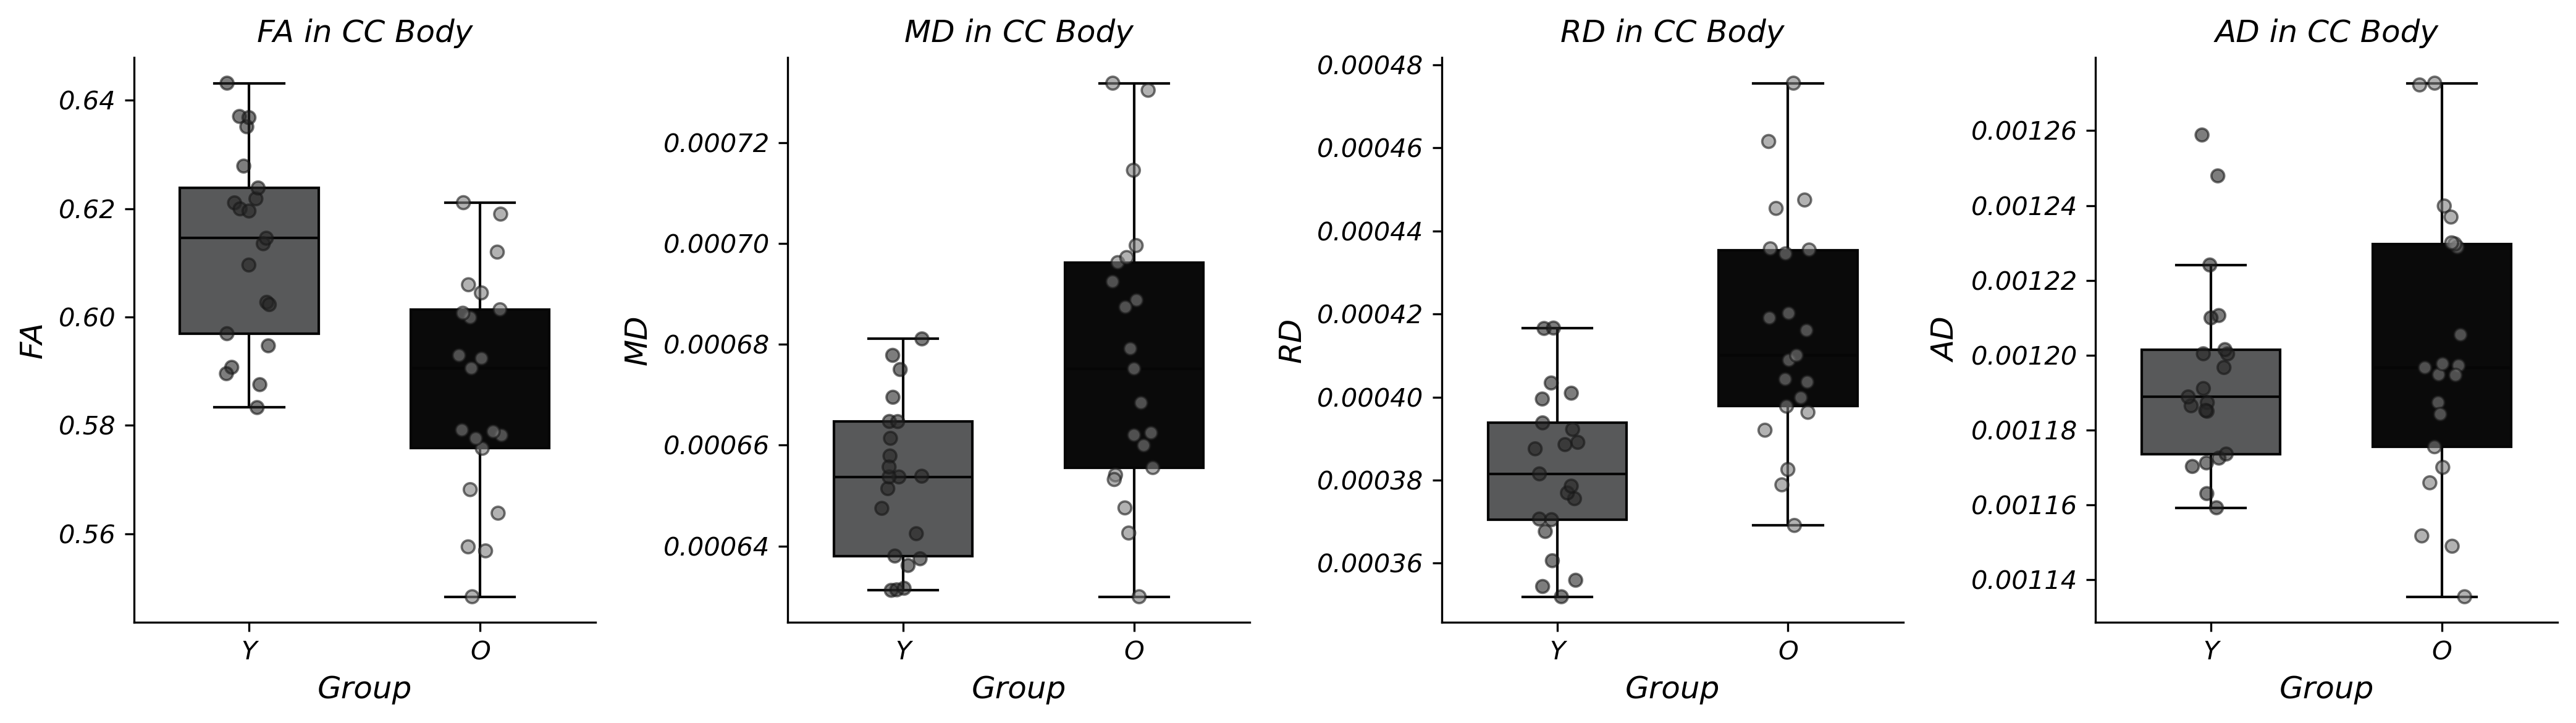

In [48]:
group_colors = {'Y': "#015ed7", 'O': "#ea231d"}
group_colors = {'Y': "#58595A89", 'O': "#0a0a0aae"}

metrics = ['FA', 'MD', 'RD', 'AD']
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    DTImetric = metric + '_body'
    sns.boxplot(x='group', y=DTImetric, data=df_CC_body, ax=ax, hue='group', palette=group_colors, showfliers=False, width=0.6, boxprops=dict(alpha=1), linewidth=1)
    sns.stripplot(x='group', y=DTImetric,data=df_CC_body, ax=ax, hue='group', marker='o', linewidth=0.9, color='gray', alpha=0.6)
    # size of the tittles
    ax.set_title(f"{metric} in CC Body", fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
# quality of the image - dpi=300
plt.rcParams['figure.dpi'] = 300
# despine
sns.despine()
plt.tight_layout()
plt.show()

In [41]:
# statistical t test for metric in metrics:
from scipy.stats import ttest_ind
for metric in metrics:
    DTImetric = metric + '_body'
    group_Y = df_CC_body[df_CC_body['group'] == 'Y'][DTImetric]
    group_Y = group_Y.dropna()
    group_O = df_CC_body[df_CC_body['group'] == 'O'][DTImetric] 
    group_O = group_O.dropna()
    t_stat, p_value = ttest_ind(group_Y, group_O)
    print(f"{metric}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
    # print descriptive statistics
    print(f"{metric} - Group Y: mean = {group_Y.mean():.3f}, std = {group_Y.std():.3f}, n = {len(group_Y)}")
    print(f"{metric} - Group O: mean = {group_O.mean():.3f}, std = {group_O.std():.3f}, n = {len(group_O)}")

FA: t-statistic = 4.328, p-value = 0.000
FA - Group Y: mean = 0.613, std = 0.018, n = 21
FA - Group O: mean = 0.587, std = 0.021, n = 21
MD: t-statistic = -3.492, p-value = 0.001
MD - Group Y: mean = 0.001, std = 0.000, n = 21
MD - Group O: mean = 0.001, std = 0.000, n = 21
RD: t-statistic = -4.570, p-value = 0.000
RD - Group Y: mean = 0.000, std = 0.000, n = 21
RD - Group O: mean = 0.000, std = 0.000, n = 21
AD: t-statistic = -0.631, p-value = 0.531
AD - Group Y: mean = 0.001, std = 0.000, n = 21
AD - Group O: mean = 0.001, std = 0.000, n = 21


FA: t-statistic = 4.328, p-value = 0.000
MD: t-statistic = -3.492, p-value = 0.001
RD: t-statistic = -4.570, p-value = 0.000
AD: t-statistic = -0.631, p-value = 0.531

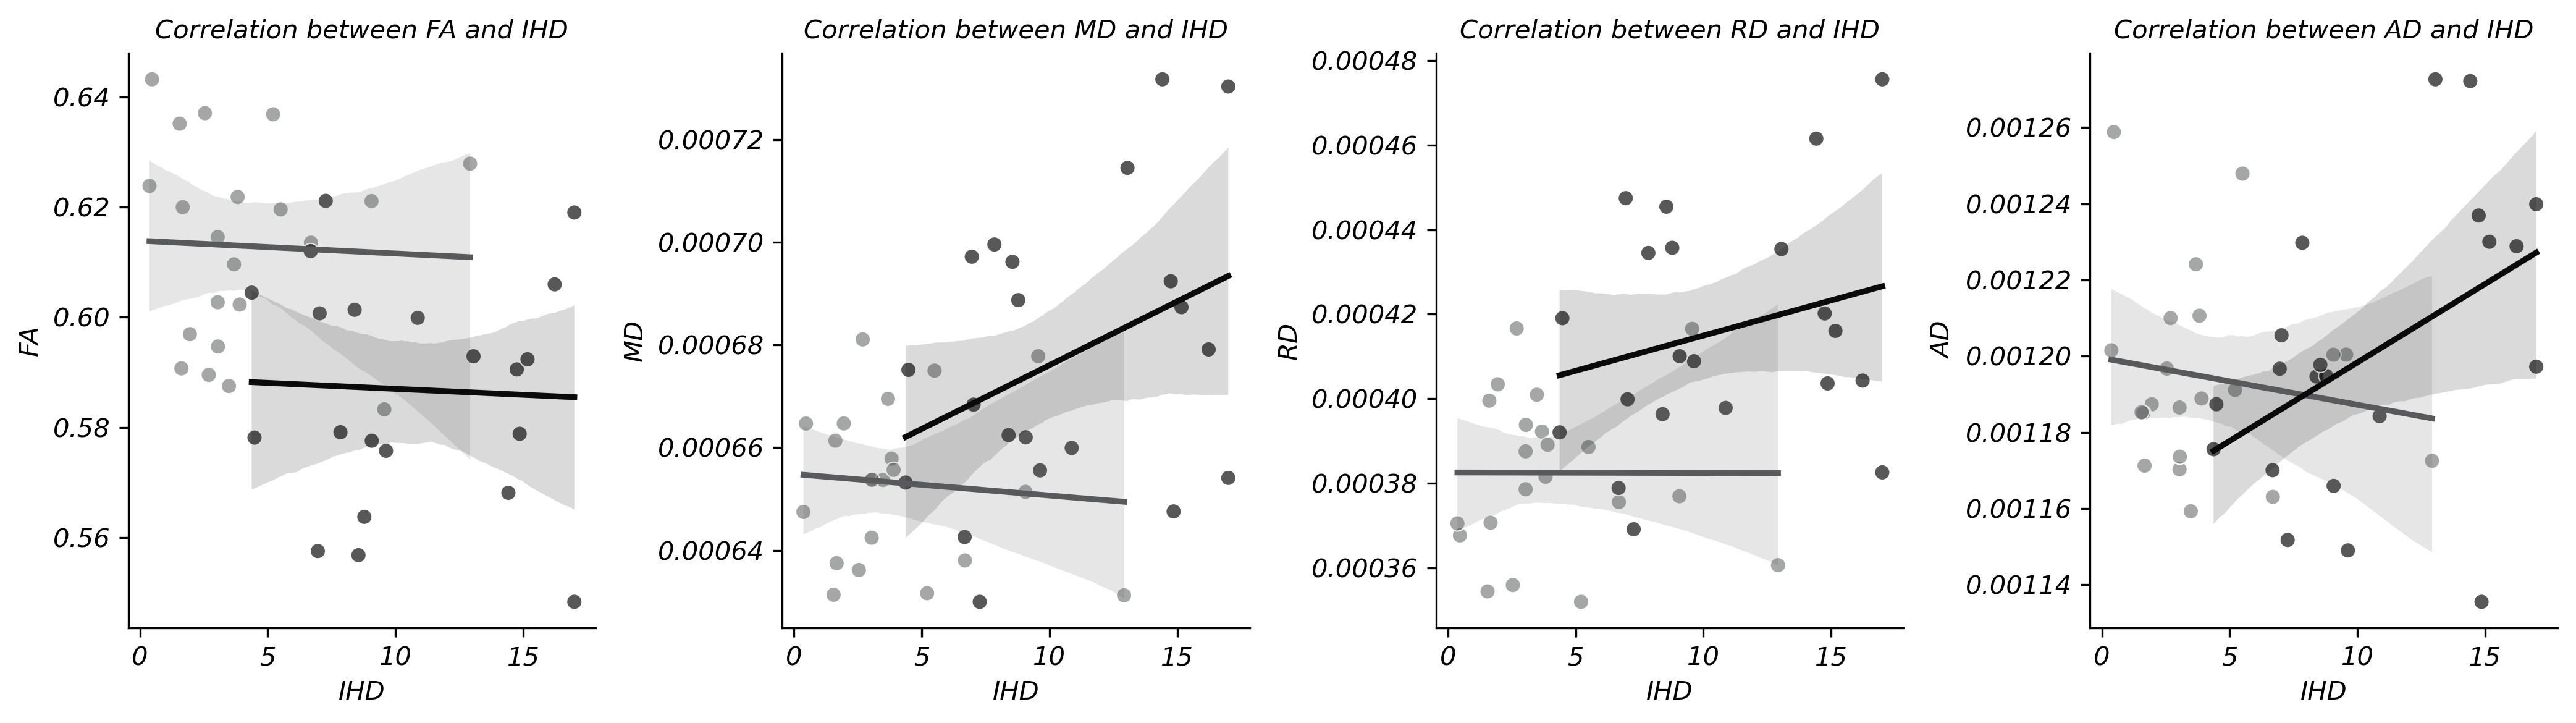

Metric: FA, Correlation: -0.40, p-value: 0.0079
Metric: MD, Correlation: 0.47, p-value: 0.0015
Metric: RD, Correlation: 0.49, p-value: 0.0010
Metric: AD, Correlation: 0.25, p-value: 0.1137
Group: Y, Metric: FA, Correlation: -0.04, p-value: 0.8612
Group: O, Metric: FA, Correlation: -0.04, p-value: 0.8537
Group: Y, Metric: MD, Correlation: -0.09, p-value: 0.7132
Group: O, Metric: MD, Correlation: 0.37, p-value: 0.1011
Group: Y, Metric: RD, Correlation: -0.00, p-value: 0.9925
Group: O, Metric: RD, Correlation: 0.25, p-value: 0.2750
Group: Y, Metric: AD, Correlation: -0.15, p-value: 0.5103
Group: O, Metric: AD, Correlation: 0.45, p-value: 0.0391


In [42]:
# correlation plots between the DTI measures in the Body_CC and the IHD, for each group
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
x_var = 'JND_P'
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, metric in zip(axes.flatten(), metrics):
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line for each group
    sns.regplot(data=df_CC_body[df_CC_body['group'] == 'Y'], x=x_var, y=DTImetric, ax=ax, scatter=False, color=group_colors['Y'])
    sns.regplot(data=df_CC_body[df_CC_body['group'] == 'O'], x=x_var, y=DTImetric, ax=ax, scatter=False, color=group_colors['O'])
    ax.set_title(f"Correlation between {metric} and IHD", fontsize=10)
    ax.set_xlabel('IHD', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    # remove the legend
    ax.get_legend().remove()
sns.despine()
plt.rcParams['figure.dpi'] = 300
plt.tight_layout()  
plt.show()

# correlations between DTI metrics in the Body_CC and the JND across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

# print correlation coefficients and p values for each group and each DTI metric    
from scipy.stats import pearsonr
for metric in metrics:
    DTImetric = metric + '_body'
    for group in ['Y', 'O']:
        subset = df_CC_body[df_CC_body['group'] == group]
        # eliminate rows with NaN values in the relevant columns
        subset = subset.dropna(subset=[DTImetric, x_var])
        corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
        print(f"Group: {group}, Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

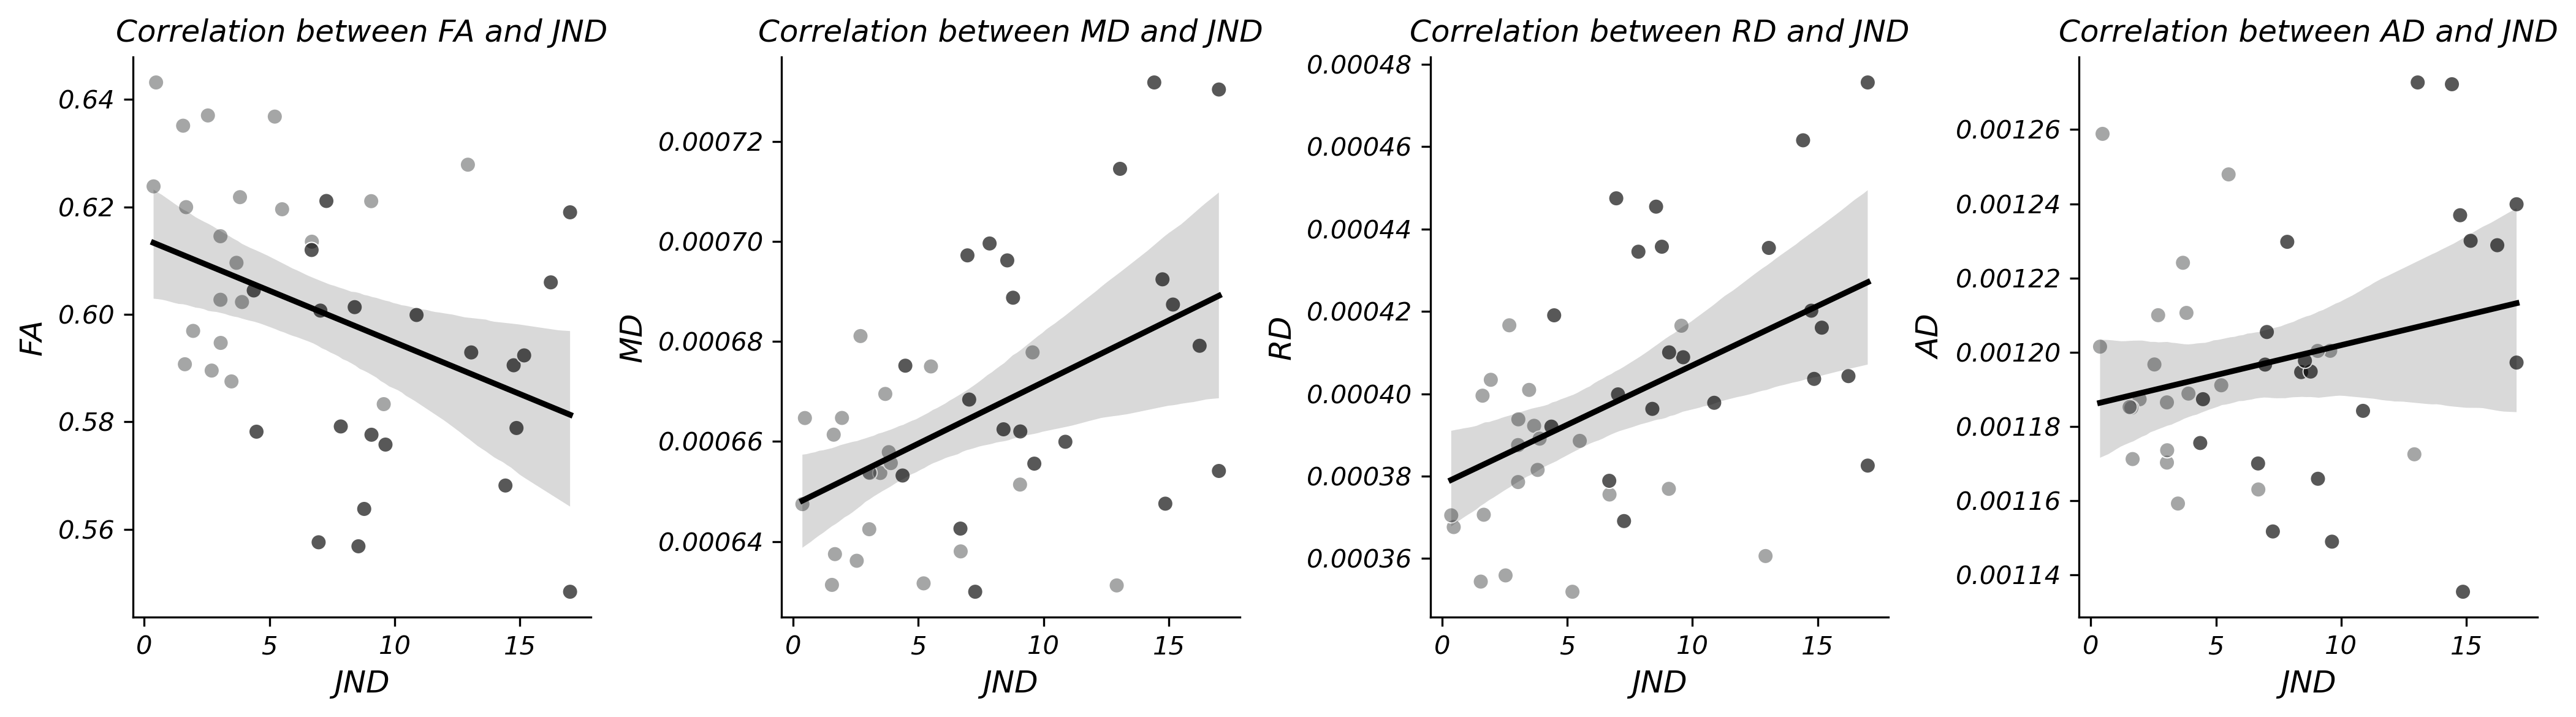

Metric: FA, Correlation: -0.40, p-value: 0.0079
Metric: MD, Correlation: 0.47, p-value: 0.0015
Metric: RD, Correlation: 0.49, p-value: 0.0010
Metric: AD, Correlation: 0.25, p-value: 0.1137


In [43]:
# correlations between DTI metrics in the Body_CC and the JND across all population, hue by color group
x_var = 'JND_P'
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, metric in zip(axes.flatten(), metrics): 
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line  for all
    sns.regplot(data=df_CC_body, x=x_var, y=DTImetric, ax=ax, scatter=False, color='black')
    ax.set_title(f"Correlation between {metric} and JND", fontsize=12)
    ax.set_xlabel('JND', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.get_legend().remove()
sns.despine()
plt.rcParams['figure.dpi'] = 300
plt.tight_layout()
plt.show()

# correlations between DTI metrics in the Body_CC and the JND across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

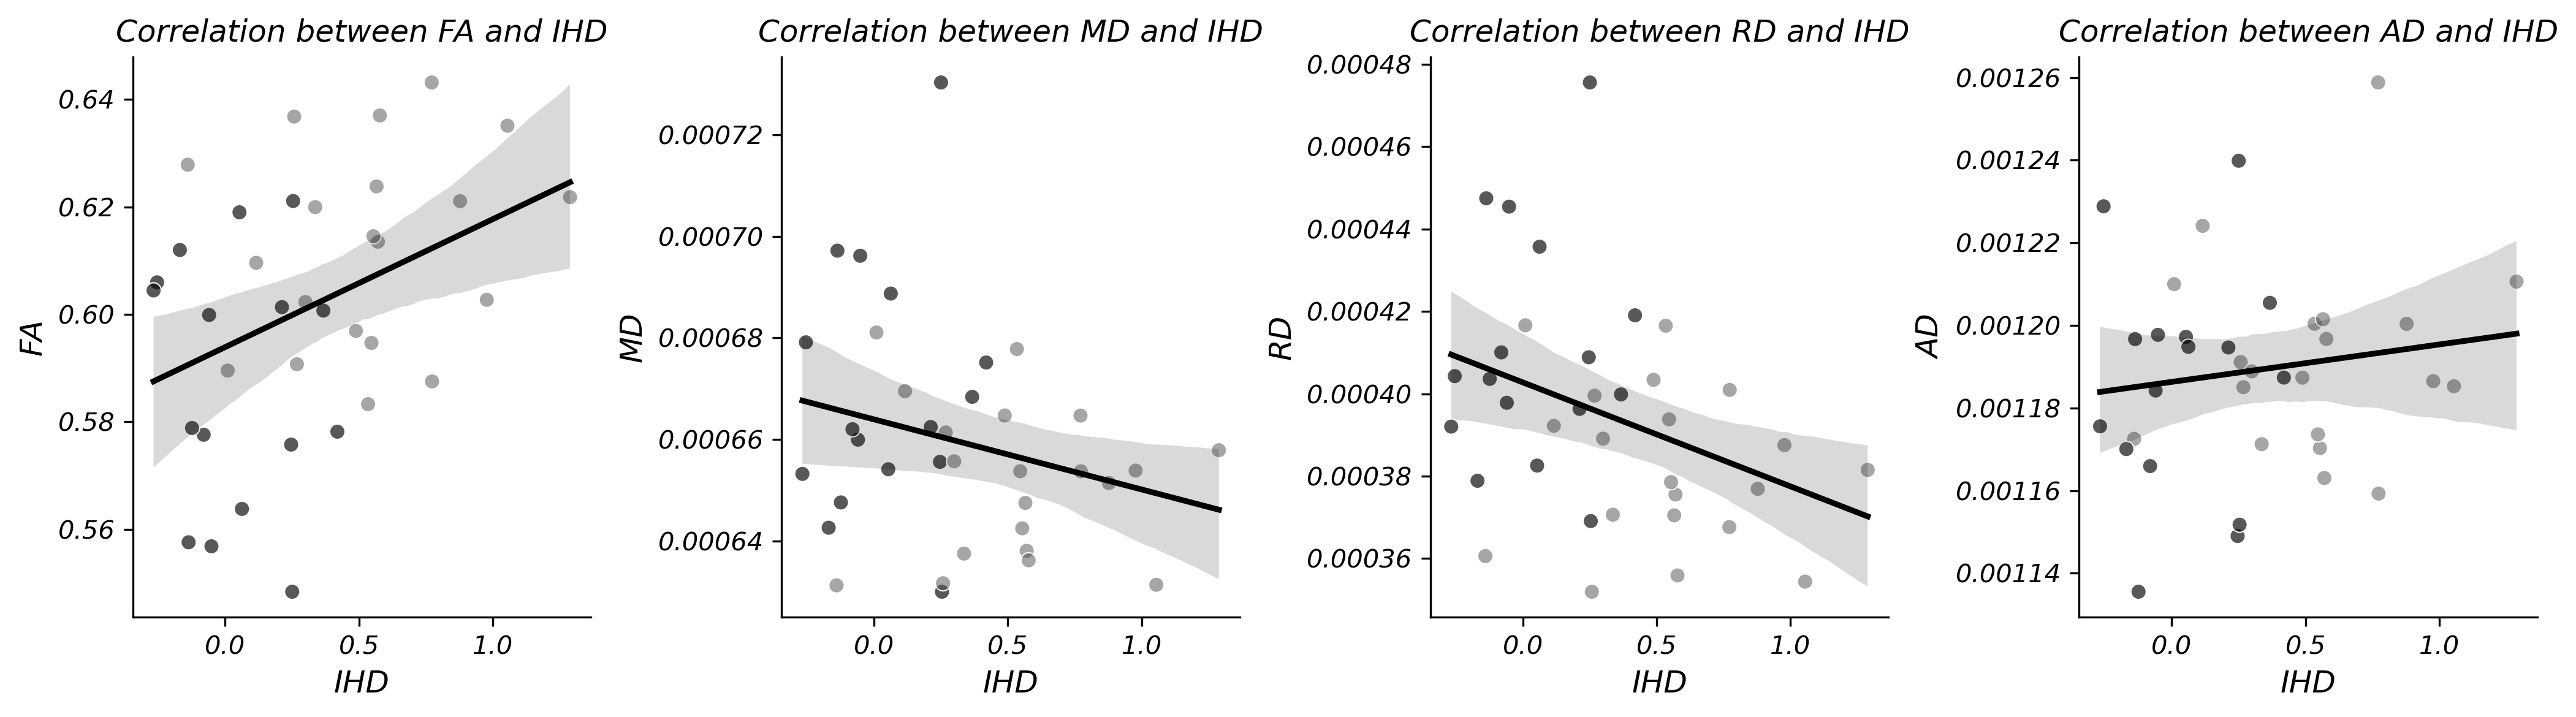

Metric: FA, Correlation: 0.39, p-value: 0.0203
Metric: MD, Correlation: -0.25, p-value: 0.1416
Metric: RD, Correlation: -0.36, p-value: 0.0316
Metric: AD, Correlation: 0.14, p-value: 0.4125


In [44]:
# correlations between DTI metrics in the Body_CC and the IHD across all population, hue by color group
x_var = 'IHD'
fig, axes = plt.subplots(1, 4, figsize=(14,4))
for ax, metric in zip(axes.flatten(), metrics): 
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line  for all
    sns.regplot(data=df_CC_body, x=x_var, y=DTImetric, ax=ax, scatter=False, color='black')
    ax.set_title(f"Correlation between {metric} and IHD", fontsize=12)
    ax.set_xlabel('IHD', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.get_legend().remove()
sns.despine()
plt.rcParams['figure.dpi'] = 300
plt.tight_layout()
plt.show()

# correlations between DTI metrics in the Body_CC and the IHD across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")